In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv('../data/processed/sentiment_encoded.csv')

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,label
0,0,0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),1
1,1,1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),2
2,2,2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),1
3,3,3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),0
4,4,4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),0


In [4]:
import joblib

In [5]:
tfidf = joblib.load("../models/tfidf/tfidf_vectorizer.pkl")

In [19]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"D:\airline-complaint-intelligence")

sys.path.append(str(PROJECT_ROOT))

In [20]:
from src.preprocessing.textcleaning import clean_text

In [21]:
x=df['text'].apply(clean_text)

In [23]:
y=df['label']

In [22]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [25]:
x_train_vector=tfidf.transform(x_train)
x_test_vector=tfidf.transform(x_test)


In [27]:
print(x_train_vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 236944 stored elements and shape (11561, 10000)>
  Coords	Values
  (0, 572)	0.10610591867426244
  (0, 690)	0.3546866874600133
  (0, 1738)	0.2094604373167652
  (0, 1742)	0.24819087976930962
  (0, 2513)	0.23934790569219602
  (0, 2514)	0.3670158969562742
  (0, 4216)	0.12141744898098837
  (0, 4382)	0.11703665308608424
  (0, 4410)	0.3496388521557939
  (0, 8389)	0.07892090418596648
  (0, 8438)	0.2549463937962956
  (0, 8834)	0.2024682367234647
  (0, 8836)	0.20734360875367155
  (0, 9281)	0.23756934899581528
  (0, 9284)	0.33070319683764454
  (0, 9899)	0.13744832674803242
  (0, 9985)	0.27365038873547726
  (1, 357)	0.1745068895868255
  (1, 1153)	0.11086189262081372
  (1, 1561)	0.10207496296634326
  (1, 1614)	0.1497690683937328
  (1, 3873)	0.20516738737546758
  (1, 3887)	0.1210599711109056
  (1, 4498)	0.09210667485903265
  (1, 4546)	0.2501420681989766
  :	:
  (11558, 6607)	0.2532820629086763
  (11558, 7034)	0.15308452389468422
  (11558,

In [28]:
from sklearn.naive_bayes import MultinomialNB

In [29]:
MultinomialNB_model=MultinomialNB()

In [30]:
MultinomialNB_model.fit(x_train_vector,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[7287.,2448.,1826.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-0.46,-1.55,-1.85]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 10000)","[[2.63,3.96,0. ,...,3.09,6.26,1.06], [0.3 ,1.23,0.6 ,...,0. ,0.26,0.62], [0. ,1.37,0.69,...,0.25,0.26,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 10000)","[[ -9.37, -9.06,-10.66,..., -9.25, -8.68, -9.94], [ -9.57, -9.03, -9.36,..., -9.83, -9.6 , -9.35], [ -9.71, -8.84, -9.19,..., -9.48, -9.48, -9.71]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [32]:
y_predict=MultinomialNB_model.predict(x_test_vector)

In [33]:
from sklearn.metrics import accuracy_score,classification_report

In [35]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.71      0.98      0.82      1800
           1       0.72      0.23      0.35       619
           2       0.90      0.37      0.52       472

    accuracy                           0.72      2891
   macro avg       0.78      0.53      0.57      2891
weighted avg       0.74      0.72      0.67      2891



In [36]:
joblib.dump(
    MultinomialNB_model,
    "../models/tfidf/multinomailNB.pkl"
)

['../models/tfidf/multinomailNB.pkl']

In [66]:
from sklearn.metrics import  confusion_matrix

In [67]:
maxtrix_multinomailNB=confusion_matrix(y_test,y_predict)

Text(0.5, 1.0, 'Multinomial Naive Bayes')

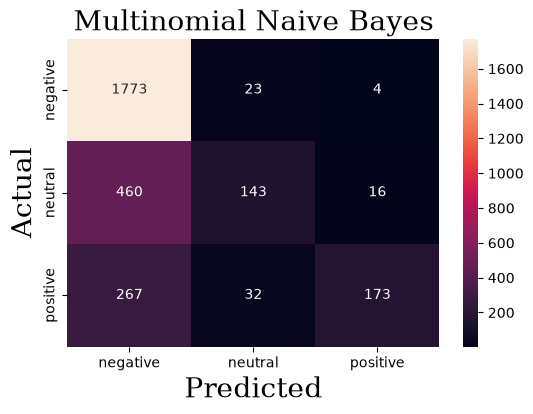

In [75]:
xtick=['negative','neutral','positive']
plt.figure(figsize=(6, 4))
sns.heatmap(maxtrix_multinomailNB,annot=True,
            fmt="d",
    xticklabels=xtick,
    yticklabels=xtick)
front_dict={'family':'serif','color':'#000','size':20}
plt.xlabel("Predicted",fontdict=front_dict)
plt.ylabel("Actual",fontdict=front_dict)
plt.title("Multinomial Naive Bayes",fontdict=front_dict)

In [37]:
from sklearn.svm import LinearSVC

In [38]:
svm_model = LinearSVC()

In [41]:
svm_model.fit(x_train_vector, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [42]:
y_pred=svm_model.predict(x_test_vector)

In [43]:
from sklearn.metrics import accuracy_score,classification_report

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1800
           1       0.65      0.56      0.60       619
           2       0.79      0.65      0.71       472

    accuracy                           0.79      2891
   macro avg       0.76      0.71      0.73      2891
weighted avg       0.79      0.79      0.79      2891



In [46]:
from sklearn.metrics import confusion_matrix

In [48]:
import seaborn as sns

In [54]:
matrix_svm=confusion_matrix(y_test,y_pred)

In [60]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Linear SVM.')

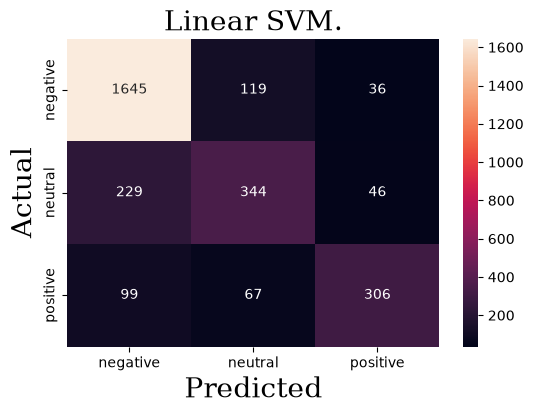

In [76]:
xtick=['negative','neutral','positive']
plt.figure(figsize=(6, 4))
sns.heatmap(matrix_svm,annot=True,
            fmt="d",
    xticklabels=xtick,
    yticklabels=xtick)
front_dict={'family':'serif','color':'#000','size':20}
plt.xlabel("Predicted",fontdict=front_dict)
plt.ylabel("Actual",fontdict=front_dict)
plt.title("Linear SVM.",fontdict=front_dict)

In [77]:
joblib.dump(svm_model,'../models/tfidf/Linear_SVM.pkl')

['../models/tfidf/Linear_SVM.pkl']

In [78]:
logistic_model=joblib.load('../models/tfidf/logistic_regression.pkl')

In [79]:
y_logistic_pred=logistic_model.predict(x_test_vector)

In [83]:
matrix_logistic=confusion_matrix(y_test,y_logistic_pred)

In [82]:
print(classification_report(y_test,y_logistic_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1800
           1       0.85      0.63      0.73       619
           2       0.91      0.71      0.80       472

    accuracy                           0.86      2891
   macro avg       0.87      0.77      0.81      2891
weighted avg       0.86      0.86      0.85      2891



Text(0.5, 1.0, 'Logistic Regression.')

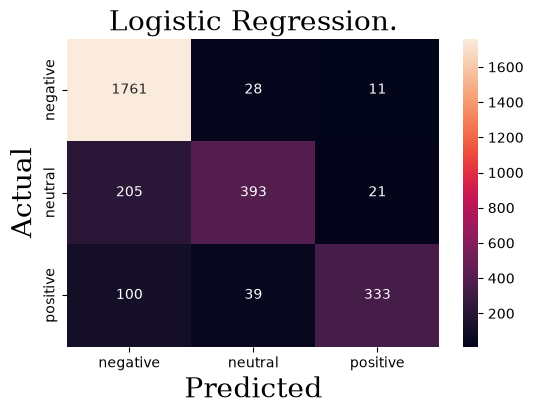

In [86]:
xtick=['negative','neutral','positive']
plt.figure(figsize=(6, 4))
sns.heatmap(matrix_logistic,annot=True,
            fmt="d",
    xticklabels=xtick,
    yticklabels=xtick)
front_dict={'family':'serif','color':'#000','size':20}
plt.xlabel("Predicted",fontdict=front_dict)
plt.ylabel("Actual",fontdict=front_dict)
plt.title("Logistic Regression.",fontdict=front_dict)

(0.0, 1.0)

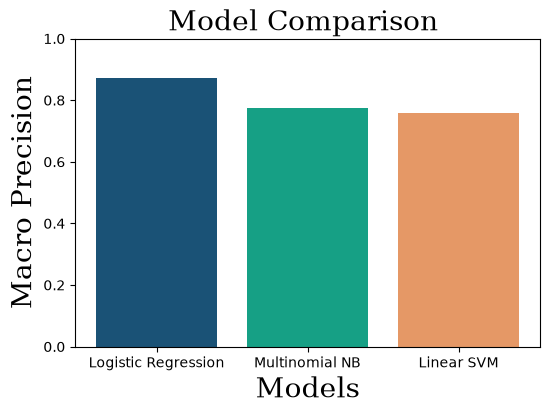

In [109]:

from sklearn.metrics import precision_score
precision_lr=precision_score(y_test,y_logistic_pred,average="macro")
precision_nb=precision_score(y_test,y_predict,average="macro")
precision_svm=precision_score(y_test,y_pred,average="macro")
front_dict={'family':'serif','color':'#000','size':20}

models = [
    "Logistic Regression",
    "Multinomial NB",
    "Linear SVM"
]

precision_scores = [
    precision_lr,
    precision_nb,
    precision_svm
]
plt.figure(figsize=(6,4))
bars = plt.bar(models, precision_scores,color=['#1A5276','#16A085','#E59866'])
plt.ylabel("Macro Precision",fontdict=front_dict)
plt.xlabel("Models",fontdict=front_dict)
plt.title("Model Comparison ",fontdict=front_dict)
plt.ylim(0, 1)


(0.0, 1.0)

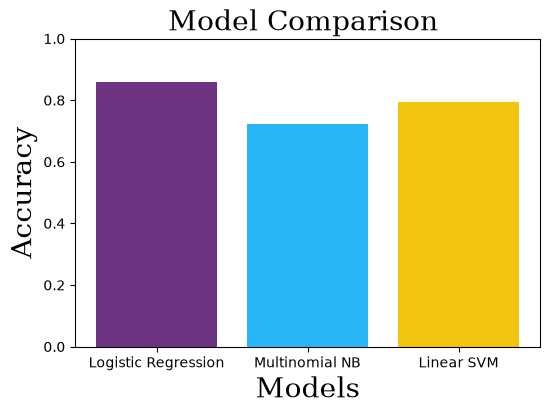

In [110]:

from sklearn.metrics import accuracy_score
accuracy_lr=accuracy_score(y_test,y_logistic_pred)
accuracy_nb=accuracy_score(y_test,y_predict)
accuracy_svm=accuracy_score(y_test,y_pred)
front_dict={'family':'serif','color':'#000','size':20}

models = [
    "Logistic Regression",
    "Multinomial NB",
    "Linear SVM"
]

precision_scores = [
    accuracy_lr,
    accuracy_nb,
    accuracy_svm
]
plt.figure(figsize=(6,4))
bars = plt.bar(models, precision_scores,color=['#6C3483','#29B6F6','#F1C40F'])
plt.ylabel("Accuracy",fontdict=front_dict)
plt.xlabel("Models",fontdict=front_dict)
plt.title("Model Comparison ",fontdict=front_dict)
plt.ylim(0, 1)


(0.0, 1.0)

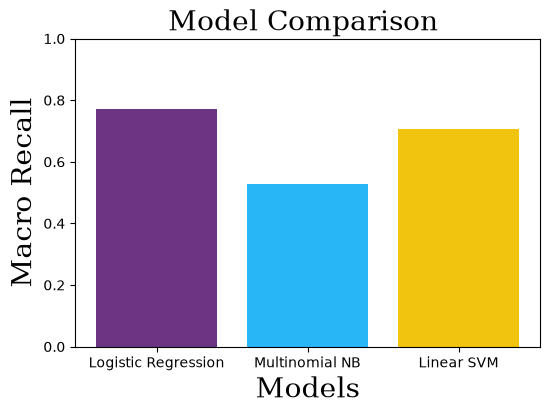

In [106]:

from sklearn.metrics import recall_score
recall_score_lr=recall_score(y_test,y_logistic_pred,average="macro")
recall_score_nb=recall_score(y_test,y_predict,average="macro")
recall_score_svm=recall_score(y_test,y_pred,average="macro")
front_dict={'family':'serif','color':'#000','size':20}

models = [
    "Logistic Regression",
    "Multinomial NB",
    "Linear SVM"
]

precision_scores = [
    recall_score_lr,
    recall_score_nb,
    recall_score_svm
]
plt.figure(figsize=(6,4))
bars = plt.bar(models, precision_scores,color=['#6C3483','#29B6F6','#F1C40F'])
plt.ylabel("Macro Recall",fontdict=front_dict)
plt.xlabel("Models",fontdict=front_dict)
plt.title("Model Comparison ",fontdict=front_dict)
plt.ylim(0, 1)


(0.0, 1.0)

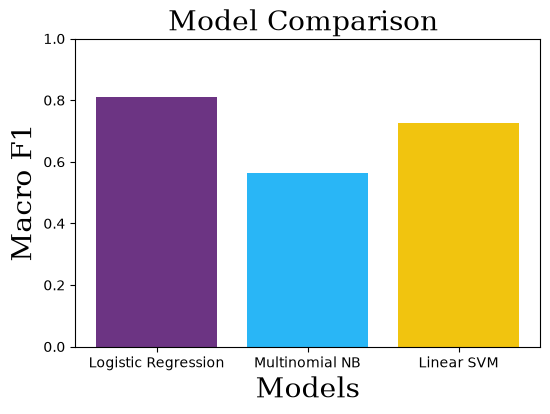

In [108]:

from sklearn.metrics import f1_score
f1_score_lr=f1_score(y_test,y_logistic_pred,average="macro")
f1_score_nb=f1_score(y_test,y_predict,average="macro")
f1_score_svm=f1_score(y_test,y_pred,average="macro")
front_dict={'family':'serif','color':'#000','size':20}

models = [
    "Logistic Regression",
    "Multinomial NB",
    "Linear SVM"
]

precision_scores = [
    f1_score_lr,
    f1_score_nb,
    f1_score_svm
]
plt.figure(figsize=(6,4))
bars = plt.bar(models, precision_scores,color=['#6C3483','#29B6F6','#F1C40F'])
plt.ylabel("Macro F1",fontdict=front_dict)
plt.xlabel("Models",fontdict=front_dict)
plt.title("Model Comparison ",fontdict=front_dict)
plt.ylim(0, 1)


In [ ]:
import pandas as pd

accuracy=[accuracy_lr,
    accuracy_nb,
    accuracy_svm]
precision=[ precision_lr,
    precision_nb,
    precision_svm]
recall=[recall_score_lr,
    recall_score_nb,
    recall_score_svm]
f1=[ f1_score_lr,
    f1_score_nb,
    f1_score_svm]
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial NB",
        "Linear SVM"
    ],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
})


In [114]:
print(comparison)
comparison.to_csv('../reports/ml_model_comparison.csv')

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.860256   0.873016  0.772912  0.811723
1       Multinomial NB  0.722587   0.775932  0.527514  0.565004
2           Linear SVM  0.793843   0.757157  0.705976  0.727465
